# Problem 1: Hiệu suất Doanh thu theo Dòng thời gian

**Môn học:** Nhập môn Phân tích Dữ liệu và AI

**Mục tiêu:** Đánh giá sức khỏe tài chính và nhận diện mô hình tăng trưởng /
sụt giảm doanh thu của siêu thị qua các tháng, dựa trên bộ dữ liệu đã chuẩn
hóa (15 bảng — `student_normalized.zip`).

**Nguồn dữ liệu sử dụng:** `orders.csv`, `order_items.csv`, `products.csv`,
`order_item_promotions.csv`, `inventory.csv`.

**Công thức doanh thu dòng (theo yêu cầu đề bài):**

$$revenue\_line = quantity \times unit\_price - discount\_amount$$

**Giả định phân tích:** Doanh thu chỉ được ghi nhận cho các đơn hàng có
`order_status != 'cancelled'` (đơn bị hủy coi như chưa từng phát sinh giao
dịch nên không tính vào doanh thu thực tế). Các trạng thái còn lại
(`delivered`, `returned`, `shipped`, `paid`, `created`) vẫn được giữ lại vì
giao dịch đã thực sự phát sinh tại thời điểm đặt hàng — phần hàng hoàn trả
sẽ được phân tích riêng ở nhóm `returns/return_items` (ngoài phạm vi
Problem 1).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

from google.colab import files
uploaded = files.upload()



Saving student_normalized.zip to student_normalized (1).zip


## 1. Nạp dữ liệu và xây dựng bảng phân tích (fact table)

Ghép `order_items` với `orders` (lấy ngày đặt hàng, trạng thái) và
`products` (lấy `category`), sau đó tính `revenue_line` cho từng dòng đơn
hàng.

In [15]:
import os
import zipfile
import pandas as pd

os.makedirs('charts', exist_ok=True)

# Tìm file zip đã được tải lên để giải nén trực tiếp vào thư mục hiện tại
zip_files = [f for f in os.listdir('.') if f.endswith('.zip') and 'student_normalized' in f]
if zip_files:
    zip_files.sort()  # Ưu tiên lấy file mới nhất
    target_zip = zip_files[-1]
    print(f"Đang giải nén dữ liệu từ: {target_zip} vào thư mục hiện tại...")
    with zipfile.ZipFile(target_zip, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Giải nén thành công!")
else:
    print("Cảnh báo: Không tìm thấy file zip dữ liệu nào trong thư mục hiện tại.")

# Đọc dữ liệu trực tiếp không dùng DATA_DIR
order_items = pd.read_csv('order_items.csv')
orders = pd.read_csv('orders.csv', usecols=['order_id', 'order_date', 'order_status'])
products = pd.read_csv('products.csv', usecols=['product_id', 'product_name', 'category'])
order_item_promotions = pd.read_csv('order_item_promotions.csv')
inventory = pd.read_csv('inventory.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

fact = (
    order_items
    .merge(orders, on='order_id', how='left')
    .merge(products, on='product_id', how='left')
)

fact['revenue_line'] = fact['quantity'] * fact['unit_price'] - fact['discount_amount']

print(f"Tổng số dòng order_items: {len(fact):,}")
print(f"Khoảng thời gian dữ liệu: {fact['order_date'].min().date()} -> {fact['order_date'].max().date()}")
print("\nPhân bố order_status:")
print(fact['order_status'].value_counts())

fact_valid = fact[fact['order_status'] != 'cancelled'].copy()
fact_valid['month'] = fact_valid['order_date'].dt.to_period('M').dt.to_timestamp()

print(f"\nSau khi loại 'cancelled': {len(fact_valid):,} dòng, {fact_valid['month'].nunique()} tháng dữ liệu.")

Đang giải nén dữ liệu từ: student_normalized.zip vào thư mục hiện tại...
Giải nén thành công!
Tổng số dòng order_items: 714,669
Khoảng thời gian dữ liệu: 2012-07-04 -> 2022-12-31

Phân bố order_status:
order_status
delivered    570887
cancelled     65673
returned      40034
shipped       15094
paid          14987
created        7994
Name: count, dtype: int64

Sau khi loại 'cancelled': 648,996 dòng, 126 tháng dữ liệu.


## Problem statement 1 — Tổng doanh thu thực tế (sau chiết khấu)

`Metric: SUM(revenue_line)` theo tháng → **Net Monthly Revenue (KPI)**.

In [16]:
monthly_revenue = fact_valid.groupby('month')['revenue_line'].agg(
    net_revenue='sum', n_lines='count', avg_line_revenue='mean'
).sort_index()

total_revenue = monthly_revenue['net_revenue'].sum()
print(f"TỔNG DOANH THU THỰC TẾ TOÀN GIAI ĐOẠN: {total_revenue:,.0f}")
print(f"Doanh thu trung bình / tháng: {monthly_revenue['net_revenue'].mean():,.0f}")
monthly_revenue.head()


TỔNG DOANH THU THỰC TẾ TOÀN GIAI ĐOẠN: 14,233,855,628
Doanh thu trung bình / tháng: 112,967,108


,net_revenue,n_lines,avg_line_revenue
month,,,
2012-07-01,"118,658,600.62",5343,"22,208.24"
2012-08-01,"143,718,488.50",6497,"22,120.75"
2012-09-01,"117,556,444.92",5374,"21,875.04"
2012-10-01,"100,929,930.73",4479,"22,534.03"
2012-11-01,"87,737,668.80",4394,"19,967.61"


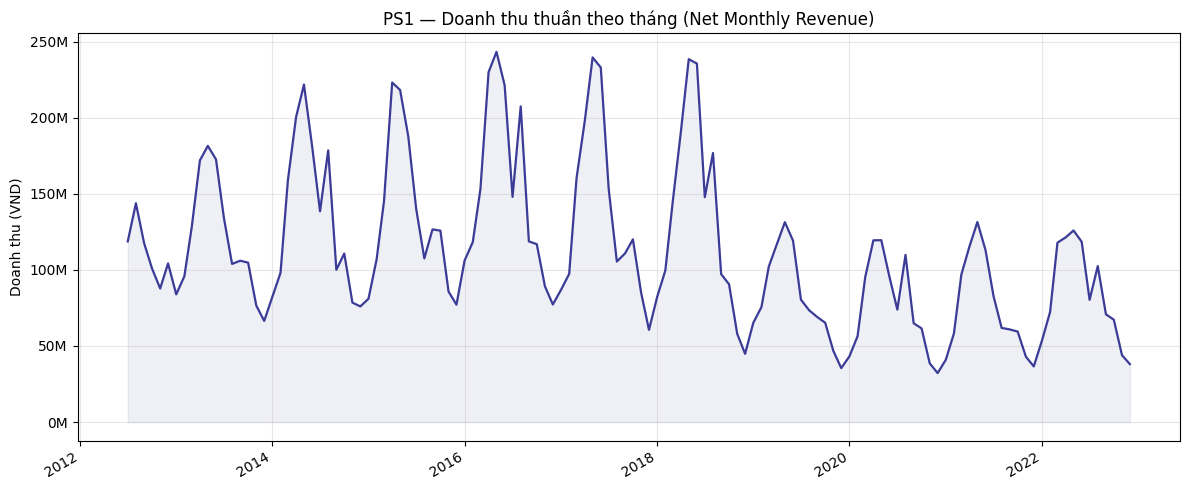

In [17]:
fig, ax = plt.subplots()
ax.plot(monthly_revenue.index, monthly_revenue['net_revenue'], color='#3b3b98', lw=1.6)
ax.fill_between(monthly_revenue.index, monthly_revenue['net_revenue'], alpha=0.08, color='#3b3b98')
ax.set_title('PS1 — Doanh thu thuần theo tháng (Net Monthly Revenue)')
ax.set_ylabel('Doanh thu (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts/ps1_monthly_revenue.png', dpi=130)
plt.show()


**Nhận xét:** Doanh thu dao động mạnh giữa các tháng thay vì tăng trưởng
đều — cần phân tích sâu hơn ở PS3/PS4 để tìm nguyên nhân và mức độ ổn định.

## Problem statement 2 — Tỷ trọng đóng góp doanh thu theo `category` theo tháng

`% tỷ trọng = revenue_category_tháng / tổng_revenue_tháng × 100`, kèm độ
lệch tỷ trọng so với tháng liền trước để phát hiện biến động cơ cấu sản
phẩm.

In [18]:
cat_month_revenue = (fact_valid.groupby(['month', 'category'])['revenue_line']
                      .sum().unstack(fill_value=0).sort_index())
cat_month_share = cat_month_revenue.div(cat_month_revenue.sum(axis=1), axis=0) * 100

print("Các category:", list(cat_month_revenue.columns))
print("\nTỷ trọng doanh thu trung bình theo category (toàn giai đoạn):")
print((cat_month_revenue.sum() / cat_month_revenue.sum().sum() * 100).round(2).sort_values(ascending=False))


Các category: ['Casual', 'GenZ', 'Outdoor', 'Streetwear']

Tỷ trọng doanh thu trung bình theo category (toàn giai đoạn):
category
Streetwear   80.11
Outdoor      14.98
Casual        2.81
GenZ          2.10
dtype: float64


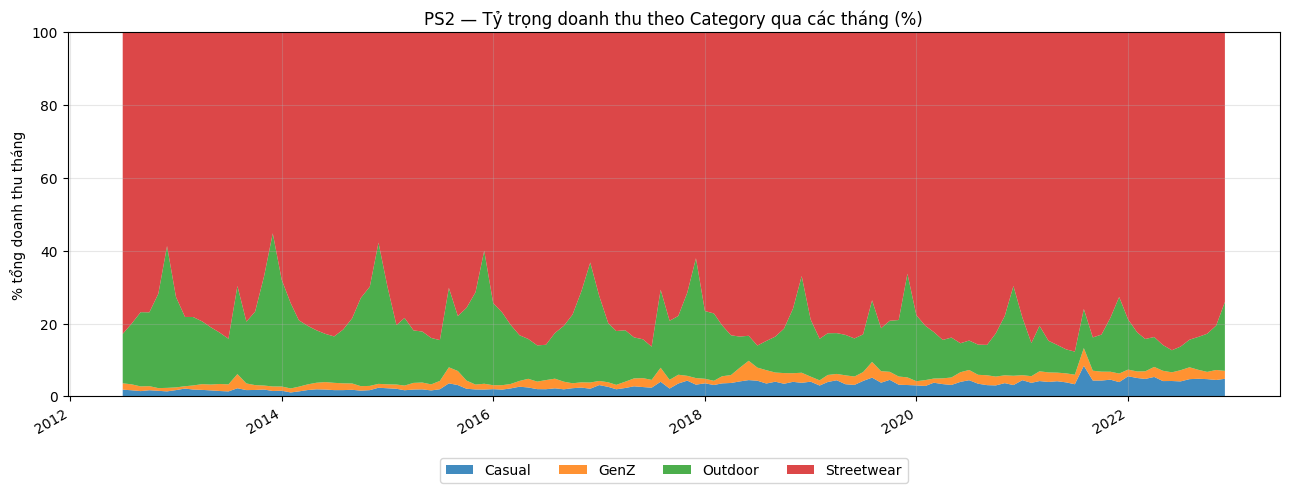

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(cat_month_share.index, cat_month_share.T.values,
             labels=cat_month_share.columns, alpha=0.85)
ax.set_title('PS2 — Tỷ trọng doanh thu theo Category qua các tháng (%)')
ax.set_ylabel('% tổng doanh thu tháng')
ax.set_ylim(0, 100)
ax.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.15))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts/ps2_category_share_stacked.png', dpi=130)
plt.show()


In [20]:
share_deviation = cat_month_share.diff().abs()
share_deviation['avg_abs_deviation'] = share_deviation.mean(axis=1)

top_structure_shifts = (share_deviation.drop(columns='avg_abs_deviation')
                         .stack().sort_values(ascending=False).head(10))
top_structure_shifts.index.set_names(['month', 'category'], inplace=True)
print("Top 10 biến động tỷ trọng category mạnh nhất so với tháng trước (điểm %):")
top_structure_shifts.to_frame('abs_share_change_pct')


Top 10 biến động tỷ trọng category mạnh nhất so với tháng trước (điểm %):


abs_share_change_pct
month      category                        
2017-08-01 Streetwear                 15.65
2018-01-01 Streetwear                 14.51
2013-08-01 Streetwear                 14.49
2016-01-01 Streetwear                 14.40
2015-08-01 Streetwear                 14.35
2018-01-01 Outdoor                    14.33
2013-01-01 Outdoor                    14.14
           Streetwear                 14.01
2016-01-01 Outdoor                    14.00
2012-12-01 Streetwear                 13.09

## Problem statement 3 — Tăng trưởng / suy giảm doanh thu theo tháng (MoM)

- `MoM_growth% = (revenue_t - revenue_t-1) / revenue_t-1 × 100`
- `order_count` theo tháng (đối chiếu tăng doanh thu có đến từ tăng số đơn
  hay tăng giá trị đơn hàng)
- `promo_usage_count` = số lượt `order_item` được áp dụng khuyến mãi/tháng
- **Cảnh báo:** gắn cờ khi `MoM_growth% < 0` trong ≥ 2 tháng liên tiếp.

In [21]:
order_count = fact_valid.groupby('month')['order_id'].nunique().reindex(monthly_revenue.index)

promo_lines = (order_items[['order_item_id', 'order_id']]
               .merge(order_item_promotions[['order_item_id', 'promo_id']], on='order_item_id', how='inner')
               .merge(orders[['order_id', 'order_date', 'order_status']], on='order_id', how='left'))
promo_lines = promo_lines[promo_lines['order_status'] != 'cancelled'].copy()
promo_lines['month'] = promo_lines['order_date'].dt.to_period('M').dt.to_timestamp()
promo_usage_count = (promo_lines.groupby('month')['order_item_id'].nunique()
                      .reindex(monthly_revenue.index, fill_value=0))

ps3 = pd.DataFrame({
    'net_revenue': monthly_revenue['net_revenue'],
    'mom_growth_pct': monthly_revenue['net_revenue'].pct_change() * 100,
    'order_count': order_count,
    'avg_order_value': monthly_revenue['net_revenue'] / order_count,
    'promo_usage_count': promo_usage_count,
})

ps3['declining_flag'] = ps3['mom_growth_pct'] < 0
ps3['consecutive_decline_alert'] = ps3['declining_flag'] & ps3['declining_flag'].shift(1, fill_value=False)

print("5 tháng TĂNG TRƯỞNG mạnh nhất:")
display_cols = ['net_revenue', 'mom_growth_pct', 'order_count', 'promo_usage_count']
print(ps3.sort_values('mom_growth_pct', ascending=False)[display_cols].head(5))

print("\n5 tháng SUY GIẢM mạnh nhất:")
print(ps3.sort_values('mom_growth_pct')[display_cols].head(5))

n_alert = ps3['consecutive_decline_alert'].sum()
print(f"\n⚠️  Số tháng bị CẢNH BÁO (suy giảm ≥ 2 tháng liên tiếp): {n_alert}")
print(ps3[ps3['consecutive_decline_alert']][display_cols])


5 tháng TĂNG TRƯỞNG mạnh nhất:
              net_revenue  mom_growth_pct  order_count  promo_usage_count
month                                                                    
2020-03-01  95,108,355.76           68.63         3292               2007
2021-03-01  96,861,522.74           66.19         3638               2139
2017-03-01 160,282,267.00           64.71         6438               4234
2022-03-01 117,865,948.80           62.98         3843               2128
2014-03-01 158,917,323.81           62.12         7009               4070

5 tháng SUY GIẢM mạnh nhất:
              net_revenue  mom_growth_pct  order_count  promo_usage_count
month                                                                    
2018-09-01  97,169,786.21          -45.02         3764               3766
2014-09-01 100,049,074.60          -43.94         4799               4927
2016-09-01 118,669,551.57          -42.77         5088               5023
2020-09-01  64,859,324.15          -40.93         23

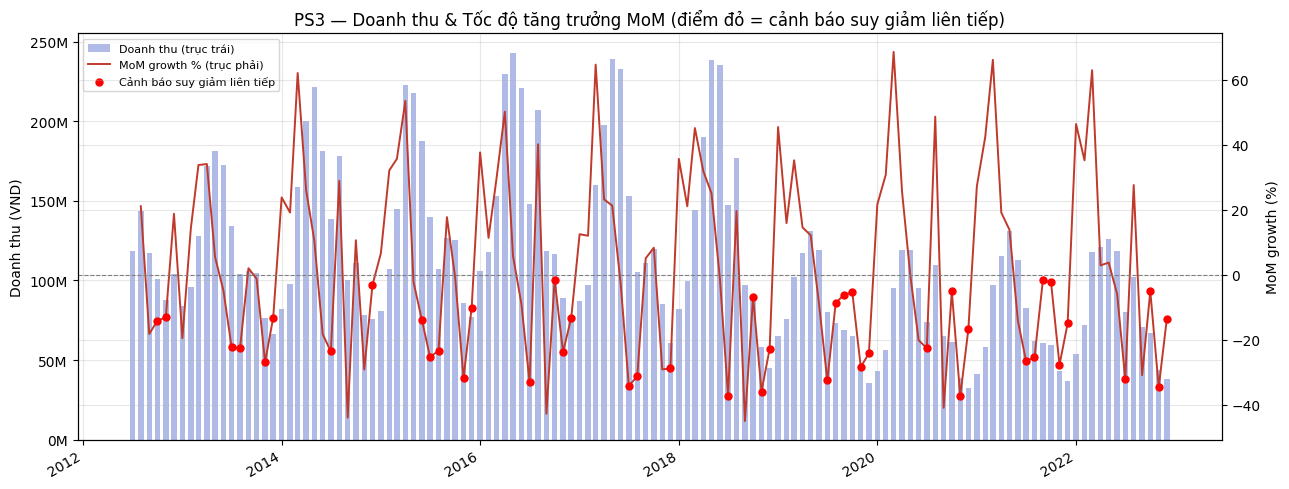

In [22]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(ps3.index, ps3['net_revenue'], width=20, color='#7a8fd6', alpha=0.6, label='Doanh thu (trục trái)')
ax1.set_ylabel('Doanh thu (VND)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M'))

ax2 = ax1.twinx()
ax2.plot(ps3.index, ps3['mom_growth_pct'], color='#c0392b', lw=1.4, label='MoM growth % (trục phải)')
ax2.axhline(0, color='grey', lw=0.8, ls='--')
alert_pts = ps3[ps3['consecutive_decline_alert']]
ax2.scatter(alert_pts.index, alert_pts['mom_growth_pct'], color='red', zorder=5, s=25,
            label='Cảnh báo suy giảm liên tiếp')
ax2.set_ylabel('MoM growth (%)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.set_title('PS3 — Doanh thu & Tốc độ tăng trưởng MoM (điểm đỏ = cảnh báo suy giảm liên tiếp)')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts/ps3_mom_growth.png', dpi=130)
plt.show()


**Phân tích nguyên nhân (đối chiếu order_count & promo_usage_count):**
Tính tương quan giữa thay đổi doanh thu và thay đổi số đơn hàng / lượt
khuyến mãi để xem tăng trưởng đến từ *nhiều đơn hơn* hay *giá trị đơn cao
hơn* / *khuyến mãi nhiều hơn*.

In [23]:
corr_df = pd.DataFrame({
    'delta_revenue': ps3['net_revenue'].diff(),
    'delta_order_count': ps3['order_count'].diff(),
    'delta_promo_usage': ps3['promo_usage_count'].diff(),
}).dropna()

corr = corr_df.corr()['delta_revenue']
print("Tương quan giữa Δdoanh thu và:")
print(f"  Δ số đơn hàng      : {corr['delta_order_count']:.3f}")
print(f"  Δ lượt dùng khuyến mãi: {corr['delta_promo_usage']:.3f}")
print("\n=> Hệ số tương quan với Δ số đơn hàng cao hơn hẳn cho thấy biến động "
      "doanh thu theo tháng chủ yếu đến từ BIẾN ĐỘNG SỐ LƯỢNG ĐƠN HÀNG, "
      "không phải do thay đổi giá trị trung bình đơn hay mức độ khuyến mãi.")


Tương quan giữa Δdoanh thu và:
  Δ số đơn hàng      : 0.648
  Δ lượt dùng khuyến mãi: -0.324

=> Hệ số tương quan với Δ số đơn hàng cao hơn hẳn cho thấy biến động doanh thu theo tháng chủ yếu đến từ BIẾN ĐỘNG SỐ LƯỢNG ĐƠN HÀNG, không phải do thay đổi giá trị trung bình đơn hay mức độ khuyến mãi.


## Problem statement 4 — Độ ổn định doanh thu theo `category`

Với chuỗi doanh thu 126 tháng/category:
- `CV = std_revenue / mean_revenue`
- `trend_slope`: hồi quy tuyến tính đơn giản `revenue ~ tháng`
- Ngưỡng phân loại: `CV > 0.35` → *Biến động mạnh*; `slope%/tháng > +0.3%`
  → *Tăng trưởng*; `< -0.3%` → *Suy giảm*; còn lại → *Ổn định* (thứ tự ưu
  tiên: biến động mạnh được xét trước vì nó phủ nhận tính "ổn định" dù
  slope có gần 0).

In [24]:
x = np.arange(len(cat_month_revenue))
rows = []
for cat in cat_month_revenue.columns:
    y = cat_month_revenue[cat].values
    mean_r, std_r = y.mean(), y.std(ddof=1)
    cv = std_r / mean_r
    slope, intercept = np.polyfit(x, y, 1)
    slope_pct = slope / mean_r * 100
    rows.append((cat, mean_r, std_r, cv, slope_pct))

stability = pd.DataFrame(rows, columns=['category', 'mean_revenue', 'std_revenue', 'CV', 'slope_pct_per_month'])

def classify_stability(r):
    if r['CV'] > 0.35:
        return 'Biến động mạnh'
    if r['slope_pct_per_month'] > 0.3:
        return 'Tăng trưởng'
    if r['slope_pct_per_month'] < -0.3:
        return 'Suy giảm'
    return 'Ổn định'

stability['classification'] = stability.apply(classify_stability, axis=1)
stability = stability.sort_values('mean_revenue', ascending=False).reset_index(drop=True)
stability


,category,mean_revenue,std_revenue,CV,slope_pct_per_month,classification
0,Streetwear,"90,496,320.55","45,331,032.17",0.50,-0.44,Biến động mạnh
1,Outdoor,"16,926,590.35","8,160,417.92",0.48,-1.10,Biến động mạnh
2,Casual,"3,169,208.09","1,655,934.44",0.52,0.39,Biến động mạnh
3,GenZ,"2,374,989.17","1,699,090.64",0.72,-0.06,Biến động mạnh


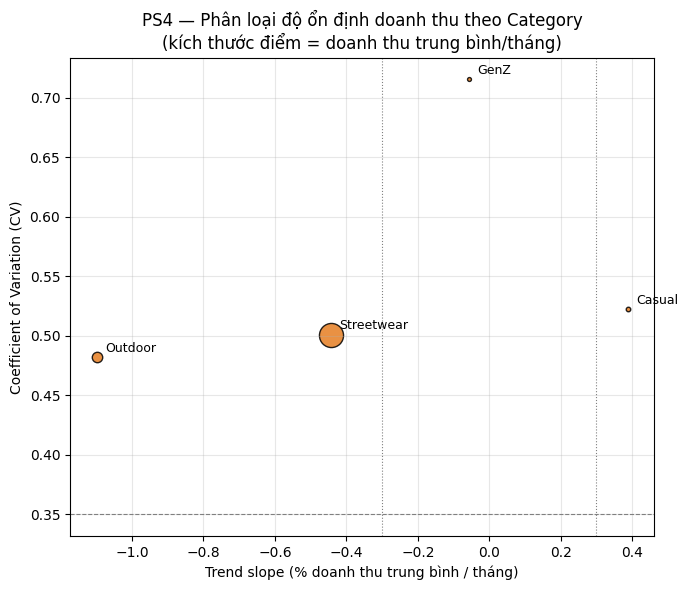


Ưu tiên đầu tư / cải thiện chiến lược bán hàng:
  - Nhóm 'Biến động mạnh': Streetwear, Outdoor, Casual, GenZ


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = {'Ổn định': '#27ae60', 'Tăng trưởng': '#2980b9', 'Biến động mạnh': '#e67e22', 'Suy giảm': '#c0392b'}
for _, r in stability.iterrows():
    ax.scatter(r['slope_pct_per_month'], r['CV'], s=r['mean_revenue']/3e5,
               color=colors[r['classification']], edgecolor='k', alpha=0.85)
    ax.annotate(r['category'], (r['slope_pct_per_month'], r['CV']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)
ax.axhline(0.35, color='grey', ls='--', lw=0.8)
ax.axvline(0.3, color='grey', ls=':', lw=0.8)
ax.axvline(-0.3, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Trend slope (% doanh thu trung bình / tháng)')
ax.set_ylabel('Coefficient of Variation (CV)')
ax.set_title('PS4 — Phân loại độ ổn định doanh thu theo Category\n(kích thước điểm = doanh thu trung bình/tháng)')
plt.tight_layout()
plt.savefig('charts/ps4_category_stability.png', dpi=130)
plt.show()

print("\nƯu tiên đầu tư / cải thiện chiến lược bán hàng:")
for cls in ['Suy giảm', 'Biến động mạnh']:
    cats = stability.loc[stability['classification'] == cls, 'category'].tolist()
    if cats:
        print(f"  - Nhóm '{cls}': {', '.join(cats)}")


## Problem statement 5 — Dự báo xu hướng doanh thu 3–6 tháng tới

Áp dụng **Holt-Winters (triple exponential smoothing, additive, mùa vụ =
12 tháng)** cài đặt thủ công bằng NumPy (môi trường không có `statsmodels`).
Tham số làm mượt `(alpha, beta, gamma)` được chọn bằng grid-search để tối
thiểu hóa MAPE trên tập backtest (giữ lại 6 tháng cuối làm test set).

In [26]:
def holt_winters_additive(series, season_len=12, alpha=0.3, beta=0.1, gamma=0.3, n_forecast=6):
    """Cài đặt thủ công Holt-Winters cộng tính (level + trend + seasonal)."""
    y = np.asarray(series, dtype=float)
    n = len(y)
    level = y[:season_len].mean()
    trend = (y[season_len:2*season_len].mean() - y[:season_len].mean()) / season_len
    seas = [y[i] - level for i in range(season_len)]
    levels, trends = [level], [trend]
    fitted = []
    for i in range(n):
        s_idx = i % season_len
        if i == 0:
            fitted.append(level + trend + seas[s_idx])
            continue
        last_level, last_trend = levels[-1], trends[-1]
        val = y[i]
        new_level = alpha * (val - seas[s_idx]) + (1 - alpha) * (last_level + last_trend)
        new_trend = beta * (new_level - last_level) + (1 - beta) * last_trend
        seas[s_idx] = gamma * (val - new_level) + (1 - gamma) * seas[s_idx]
        levels.append(new_level)
        trends.append(new_trend)
        fitted.append(new_level + new_trend + seas[s_idx])
    last_level, last_trend = levels[-1], trends[-1]
    forecasts = [last_level + h * last_trend + seas[(n + h - 1) % season_len] for h in range(1, n_forecast + 1)]
    return np.array(fitted), np.array(forecasts)

series = monthly_revenue['net_revenue'].values
train, test = series[:-6], series[-6:]

best_mape, best_params = None, None
for alpha in [0.15, 0.2, 0.3, 0.4, 0.5]:
    for beta in [0.05, 0.1, 0.2]:
        for gamma in [0.1, 0.2, 0.3, 0.4]:
            _, fc = holt_winters_additive(train, 12, alpha, beta, gamma, 6)
            mape = np.mean(np.abs((test - fc) / test)) * 100
            if best_mape is None or mape < best_mape:
                best_mape, best_params = mape, (alpha, beta, gamma)

alpha, beta, gamma = best_params
print(f"Tham số tối ưu (grid-search): alpha={alpha}, beta={beta}, gamma={gamma}")
print(f"Backtest MAPE (6 tháng gần nhất, mô hình chỉ train trên dữ liệu trước đó): {best_mape:.2f}%")


Tham số tối ưu (grid-search): alpha=0.15, beta=0.2, gamma=0.3
Backtest MAPE (6 tháng gần nhất, mô hình chỉ train trên dữ liệu trước đó): 4.84%


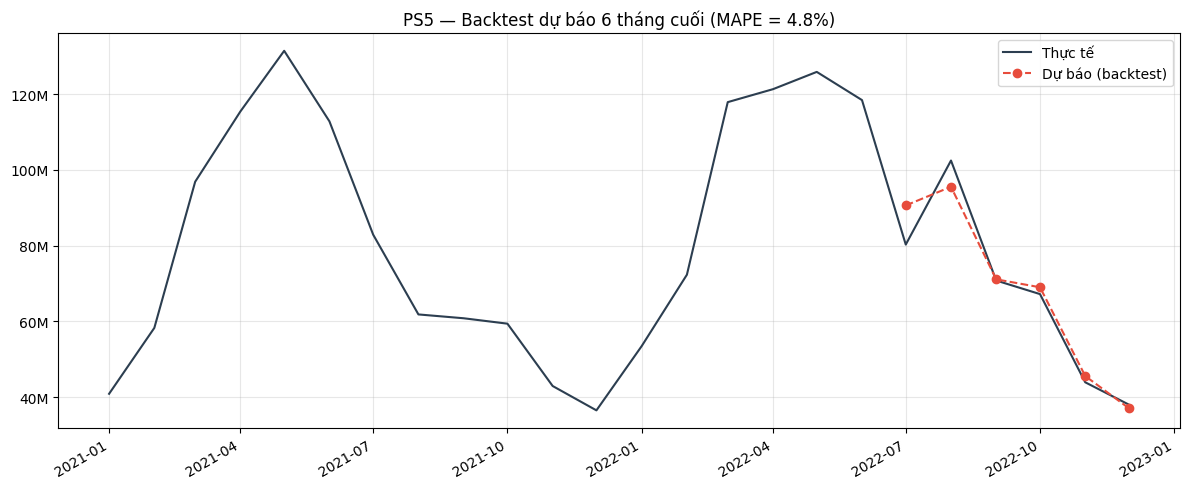

In [27]:
_, backtest_forecast = holt_winters_additive(train, 12, alpha, beta, gamma, 6)
backtest_index = monthly_revenue.index[-6:]

fig, ax = plt.subplots()
ax.plot(monthly_revenue.index[-24:], monthly_revenue['net_revenue'].values[-24:], label='Thực tế', color='#2c3e50')
ax.plot(backtest_index, backtest_forecast, label='Dự báo (backtest)', color='#e74c3c', ls='--', marker='o')
ax.set_title(f'PS5 — Backtest dự báo 6 tháng cuối (MAPE = {best_mape:.1f}%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M'))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts/ps5_backtest.png', dpi=130)
plt.show()


In [28]:
# Fit lại trên TOÀN BỘ dữ liệu để dự báo 6 tháng thực sự phía trước
fitted_full, future_forecast = holt_winters_additive(series, 12, alpha, beta, gamma, n_forecast=6)
future_index = pd.date_range(monthly_revenue.index[-1] + pd.offsets.MonthBegin(1), periods=6, freq='MS')

forecast_table = pd.DataFrame({'forecast_revenue': future_forecast}, index=future_index)
forecast_table.index.name = 'month'
print("Dự báo doanh thu 6 tháng tiếp theo:")
forecast_table


Dự báo doanh thu 6 tháng tiếp theo:


,forecast_revenue
month,
2023-01-01,"48,404,848.65"
2023-02-01,"63,410,491.16"
2023-03-01,"103,535,861.15"
2023-04-01,"127,763,854.53"
2023-05-01,"143,517,148.35"
2023-06-01,"132,265,351.14"


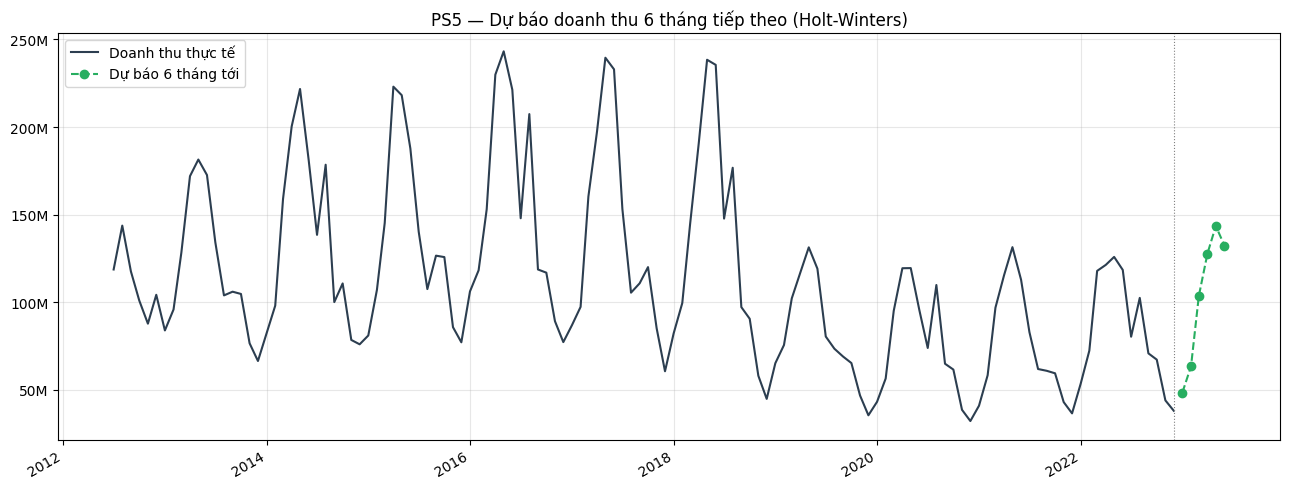

In [29]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_revenue.index, monthly_revenue['net_revenue'], label='Doanh thu thực tế', color='#2c3e50')
ax.plot(future_index, future_forecast, label='Dự báo 6 tháng tới', color='#27ae60', ls='--', marker='o')
ax.axvline(monthly_revenue.index[-1], color='grey', lw=0.8, ls=':')
ax.set_title('PS5 — Dự báo doanh thu 6 tháng tiếp theo (Holt-Winters)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M'))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts/ps5_future_forecast.png', dpi=130)
plt.show()


**Đối chiếu với `inventory.units_sold` theo category** để đề xuất kế
hoạch nhập hàng: category nào có xu hướng `units_sold` tăng trong các kỳ
snapshot gần nhất nên được ưu tiên nhập hàng thêm trước giai đoạn dự báo
tăng trưởng.

In [30]:
inv_cat = inventory.merge(products[['product_id', 'category']], on='product_id', how='left')
inv_cat['snap_month'] = inv_cat['snapshot_date'].dt.to_period('M').dt.to_timestamp()
inv_trend = inv_cat.groupby(['snap_month', 'category'])['units_sold'].sum().unstack(fill_value=0)

recent = inv_trend.tail(6)
inv_slope = pd.Series({cat: np.polyfit(np.arange(len(recent)), recent[cat].values, 1)[0]
                        for cat in recent.columns}, name='units_sold_trend_slope')
inv_slope = inv_slope.sort_values(ascending=False)
print("Xu hướng units_sold theo category (6 kỳ snapshot gần nhất, slope > 0 = đang tăng):")
print(inv_slope)

restock_priority = inv_slope[inv_slope > 0].index.tolist()
print(f"\n=> Đề xuất ưu tiên nhập hàng cho category: {restock_priority if restock_priority else 'không có category nào tăng rõ rệt'}")


Xu hướng units_sold theo category (6 kỳ snapshot gần nhất, slope > 0 = đang tăng):
Outdoor       146.80
Casual        -20.51
GenZ          -69.80
Streetwear   -358.26
Name: units_sold_trend_slope, dtype: float64

=> Đề xuất ưu tiên nhập hàng cho category: ['Outdoor']


## Tổng kết Problem 1

| PS | Kết quả chính |
|----|----------------|
| 1 | Tổng doanh thu thực tế toàn giai đoạn và doanh thu thuần theo tháng đã tính (`monthly_revenue`). |
| 2 | Tỷ trọng đóng góp doanh thu theo category theo tháng + các thời điểm biến động cơ cấu mạnh nhất (`cat_month_share`, `top_structure_shifts`). |
| 3 | Tốc độ tăng trưởng MoM, đối chiếu số đơn hàng & lượt khuyến mãi, cảnh báo các chuỗi suy giảm liên tiếp (`ps3`). |
| 4 | Phân loại 4 category theo CV & trend slope thành các nhóm ổn định/tăng trưởng/biến động/suy giảm (`stability`). |
| 5 | Dự báo Holt-Winters 6 tháng tới với MAPE backtest, đối chiếu xu hướng tồn kho để đề xuất kế hoạch nhập hàng (`forecast_table`, `restock_priority`). |

**Khuyến nghị cho ban quản lý:**
1. Doanh thu biến động mạnh theo tháng ở cả 4 category (CV > 0.35) — cần
   xây dựng chính sách tồn kho an toàn (safety stock) và kế hoạch
   marketing đều đặn hơn thay vì phụ thuộc vào các đợt khuyến mãi ngắn hạn.
2. Biến động doanh thu tương quan mạnh với biến động **số lượng đơn hàng**
   hơn là giá trị trung bình đơn hay mức khuyến mãi — ưu tiên các chương
   trình thu hút traffic/đơn hàng mới (acquisition) hơn là tăng giá trị
   giỏ hàng.
3. Sử dụng bảng dự báo 6 tháng tới (`forecast_table`) làm cơ sở đặt chỉ
   tiêu kinh doanh và phân bổ ngân sách marketing theo từng tháng.